In [1]:
import pickle as pkl

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from normalize_vendor import normalize_vendor

#### Objective:

Combine Vendors and MCC vectors into the training Dataset. 
Normalize amount. Drop problematic rows.

#### Depends on:

In [ ]:
mcc_to_vector_fname = "./data/mcc_to_vector.pkl"
vendor_to_vector_fname = "./data/vendor_to_vector.pkl"
fname = "./data/01-parsed-amounts-and-dates.parquet"

#### Generates:

In [ ]:
out_fname = "./data/05-dataframe-with-vectors.parquet"

--------------------------

In [3]:
with open(mcc_to_vector_fname, "rb") as f:
    mcc_to_vector = pkl.load(f)

with open(vendor_to_vector_fname, "rb") as f:
    vendor_to_vector = pkl.load(f)

In [4]:
df = pd.read_parquet(fname)

In [5]:
df.head()

,cohort,agency_number,agency_name,holder_last_name,holder_first_initial,amount,vendor,mcc,parsed_amount,transaction_date,posted_date
0,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,890,NACAS,CHARITABLE AND SOCIAL SERVICE ORGANIZATIONS,890.00,2013-07-30,2013-07-31
1,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,368.96,SHERATON HOTEL,SHERATON,368.96,2013-07-30,2013-07-31
2,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,J,165.82,SEARS.COM 9300,DIRCT MARKETING/DIRCT MARKETERS--NOT ELSEWHERE...,165.82,2013-07-29,2013-07-31
3,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,T,96.39,WAL-MART #0137,"GROCERY STORES,AND SUPERMARKETS",96.39,2013-07-30,2013-07-31
4,201307,1000,OKLAHOMA STATE UNIVERSITY,Mauro-Herrera,M,125.96,STAPLES DIRECT,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",125.96,2013-07-30,2013-07-31


In [6]:
df["parsed_amount"].sort_values()

272916          0.01
360721          0.01
32659           0.01
273021          0.01
67598           0.01
             ...    
251310     814934.76
365598     855343.00
251740    1089180.00
211927    1750379.98
218769    1903858.37
Name: parsed_amount, Length: 442183, dtype: float64

In [7]:
df["parsed_amount"].describe().apply(lambda x: format(x, "f"))

count     442183.000000
mean         441.297778
std         5266.813381
min            0.010000
25%           34.990000
50%          110.920000
75%          354.325000
max      1903858.370000
Name: parsed_amount, dtype: object

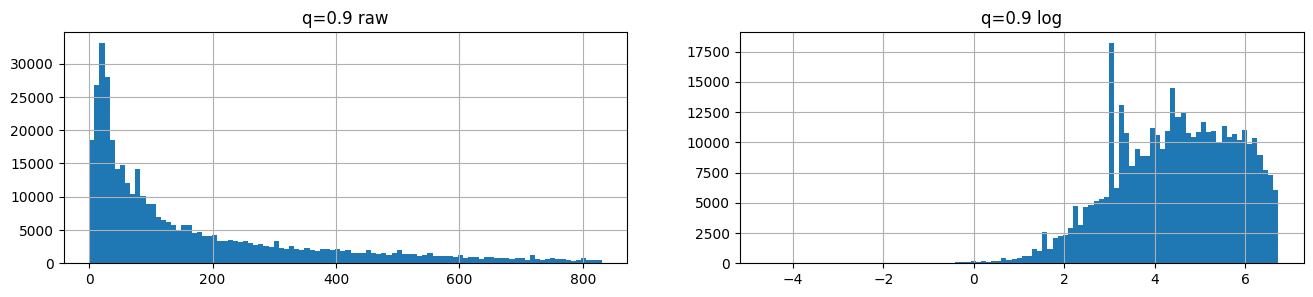

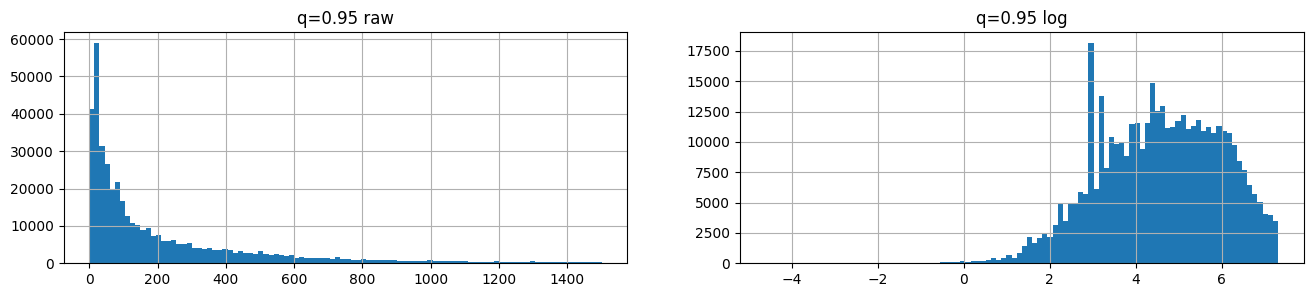

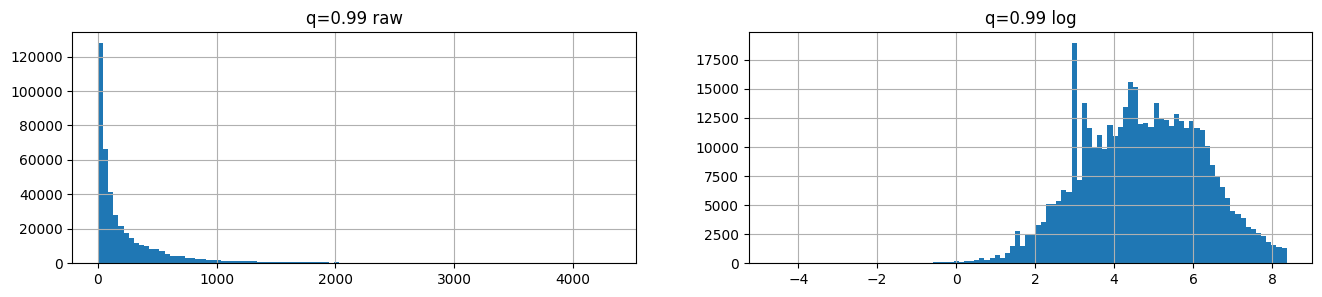

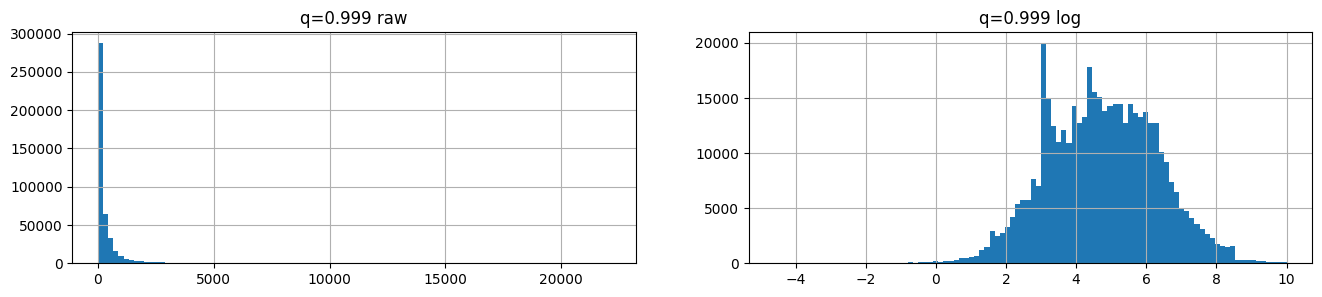

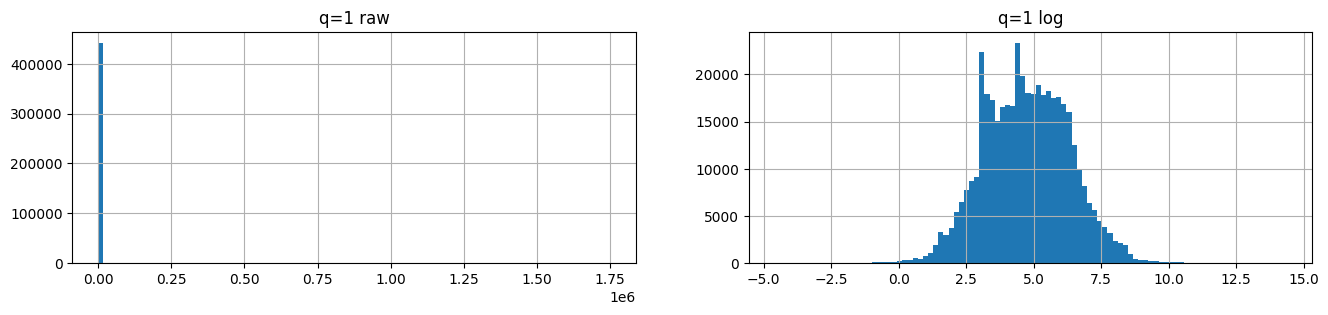

In [8]:
for q in [0.90, 0.95, 0.99, 0.999, 1]:
    plt.figure(figsize=(16, 3))
    plt.subplot(1, 2, 1)
    df[df["parsed_amount"] < df["parsed_amount"].quantile(q=q)]["parsed_amount"].hist(
        bins=100
    )
    plt.title(f"q={q} raw")

    plt.subplot(1, 2, 2)
    df[df["parsed_amount"] < df["parsed_amount"].quantile(q=q)]["parsed_amount"].apply(
        np.log
    ).hist(bins=100)
    plt.title(f"q={q} log")

    plt.show()

In [9]:
max_parsed_amount_cuttoff = df["parsed_amount"].quantile(q=0.999)
print("cuttoff:", max_parsed_amount_cuttoff)

cuttoff: 22138.761720000584


In [10]:
before_cut = len(df)
after_cut = len(df[df["parsed_amount"] < max_parsed_amount_cuttoff])
f"normalizing {before_cut - after_cut}"

'normalizing 443'

In [11]:
df.loc[
    df["parsed_amount"] > max_parsed_amount_cuttoff, "parsed_amount"
] = max_parsed_amount_cuttoff

In [12]:
min_parsed_amount_cuttoff = df["parsed_amount"].quantile(q=0.005)
print("cuttoff:", max_parsed_amount_cuttoff)

cuttoff: 22138.761720000584


In [13]:
before_cut = len(df)
after_cut = len(df[df["parsed_amount"] > min_parsed_amount_cuttoff])
f"dropping {before_cut - after_cut}. going from {before_cut} to {after_cut}"

'dropping 2229. going from 442183 to 439954'

In [14]:
df = df[df["parsed_amount"] > min_parsed_amount_cuttoff]

<Axes: >

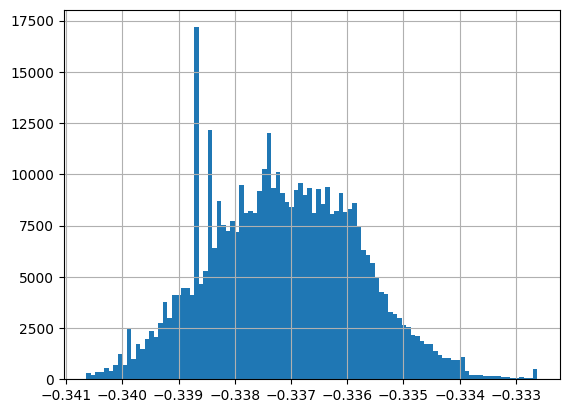

In [15]:
mean = df["parsed_amount"].mean()
std = df["parsed_amount"].std(ddof=0)


def zscore(value):
    return (value - mean) / std


df["parsed_amount"].apply(np.log).apply(zscore).hist(bins=100)

In [16]:
df["parsed_amount"] = df["parsed_amount"].apply(np.log)

In [17]:
normalizing_parameters = {
    "parsed_amount": {
        "min_cuttoff": min_parsed_amount_cuttoff,
        "max_cuttoff": max_parsed_amount_cuttoff,
    }
}

Uses the mean vendor vector if the vendor was not crawled:

In [18]:
mean_vendor_vector = np.mean(
    np.array(list(map(lambda v: vendor_to_vector[v]["mean"], vendor_to_vector.keys()))),
    axis=0,
)

In [19]:
mean_vendor_vector.shape

(768,)

In [20]:
def normalized_vendor_to_vector(v):
    if v in vendor_to_vector:
        return vendor_to_vector[v]["mean"]
    else:
        return mean_vendor_vector

In [21]:
# normalized_vendor_to_vector("AMAZON")
# normalized_vendor_to_vector("OFFICEMAX") - mean_vendor_vector

In [22]:
df_vendors_vectors = (
    df["vendor"]
    .apply(normalize_vendor)
    .apply(normalized_vendor_to_vector)
    # .apply(pd.Series)
)

In [23]:
df_vendors_vectors = pd.DataFrame(
    data=np.stack(df_vendors_vectors.values, axis=0), index=df.index
)

In [24]:
df_vendors_vectors.head()

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,0.012147,0.021508,-0.007825,-0.007432,-0.002976,0.015324,0.052413,0.011674,0.004819,-0.005618,...,-0.019914,0.001033,0.004413,0.010669,-0.000143,0.017498,0.000494,0.000393,-0.030452,-0.007612
1,0.012147,0.021508,-0.007825,-0.007432,-0.002976,0.015324,0.052413,0.011674,0.004819,-0.005618,...,-0.019914,0.001033,0.004413,0.010669,-0.000143,0.017498,0.000494,0.000393,-0.030452,-0.007612
2,0.012147,0.021508,-0.007825,-0.007432,-0.002976,0.015324,0.052413,0.011674,0.004819,-0.005618,...,-0.019914,0.001033,0.004413,0.010669,-0.000143,0.017498,0.000494,0.000393,-0.030452,-0.007612
3,0.035051,-0.007162,-0.017112,-0.003251,-0.001024,-0.000156,0.018103,0.007266,0.013443,0.020377,...,0.021358,0.023988,0.031906,0.015242,-0.038552,-0.034397,0.037363,0.024665,-0.007255,0.027484
4,0.018436,-0.008734,0.022266,-0.032007,0.006713,0.023083,0.054675,-0.001589,-0.038109,-0.003480,...,-0.028562,-0.007683,0.031480,0.004662,-0.003071,0.035726,0.015655,0.008410,-0.048161,-0.019405


In [25]:
df_vendors_vectors.rename(
    columns=dict(map(lambda x: (x, f"vendor_vector_{x}"), df_vendors_vectors.columns)),
    inplace=True,
)

In [26]:
df_vendors_vectors.head()

,vendor_vector_0,vendor_vector_1,vendor_vector_2,vendor_vector_3,vendor_vector_4,vendor_vector_5,vendor_vector_6,vendor_vector_7,vendor_vector_8,vendor_vector_9,...,vendor_vector_758,vendor_vector_759,vendor_vector_760,vendor_vector_761,vendor_vector_762,vendor_vector_763,vendor_vector_764,vendor_vector_765,vendor_vector_766,vendor_vector_767
0,0.012147,0.021508,-0.007825,-0.007432,-0.002976,0.015324,0.052413,0.011674,0.004819,-0.005618,...,-0.019914,0.001033,0.004413,0.010669,-0.000143,0.017498,0.000494,0.000393,-0.030452,-0.007612
1,0.012147,0.021508,-0.007825,-0.007432,-0.002976,0.015324,0.052413,0.011674,0.004819,-0.005618,...,-0.019914,0.001033,0.004413,0.010669,-0.000143,0.017498,0.000494,0.000393,-0.030452,-0.007612
2,0.012147,0.021508,-0.007825,-0.007432,-0.002976,0.015324,0.052413,0.011674,0.004819,-0.005618,...,-0.019914,0.001033,0.004413,0.010669,-0.000143,0.017498,0.000494,0.000393,-0.030452,-0.007612
3,0.035051,-0.007162,-0.017112,-0.003251,-0.001024,-0.000156,0.018103,0.007266,0.013443,0.020377,...,0.021358,0.023988,0.031906,0.015242,-0.038552,-0.034397,0.037363,0.024665,-0.007255,0.027484
4,0.018436,-0.008734,0.022266,-0.032007,0.006713,0.023083,0.054675,-0.001589,-0.038109,-0.003480,...,-0.028562,-0.007683,0.031480,0.004662,-0.003071,0.035726,0.015655,0.008410,-0.048161,-0.019405


In [27]:
df = pd.concat([df, df_vendors_vectors], axis=1)

In [28]:
df.head()

,cohort,agency_number,agency_name,holder_last_name,holder_first_initial,amount,vendor,mcc,parsed_amount,transaction_date,...,vendor_vector_758,vendor_vector_759,vendor_vector_760,vendor_vector_761,vendor_vector_762,vendor_vector_763,vendor_vector_764,vendor_vector_765,vendor_vector_766,vendor_vector_767
0,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,890,NACAS,CHARITABLE AND SOCIAL SERVICE ORGANIZATIONS,6.791221,2013-07-30,...,-0.019914,0.001033,0.004413,0.010669,-0.000143,0.017498,0.000494,0.000393,-0.030452,-0.007612
1,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,368.96,SHERATON HOTEL,SHERATON,5.910688,2013-07-30,...,-0.019914,0.001033,0.004413,0.010669,-0.000143,0.017498,0.000494,0.000393,-0.030452,-0.007612
2,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,J,165.82,SEARS.COM 9300,DIRCT MARKETING/DIRCT MARKETERS--NOT ELSEWHERE...,5.110903,2013-07-29,...,-0.019914,0.001033,0.004413,0.010669,-0.000143,0.017498,0.000494,0.000393,-0.030452,-0.007612
3,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,T,96.39,WAL-MART #0137,"GROCERY STORES,AND SUPERMARKETS",4.568402,2013-07-30,...,0.021358,0.023988,0.031906,0.015242,-0.038552,-0.034397,0.037363,0.024665,-0.007255,0.027484
4,201307,1000,OKLAHOMA STATE UNIVERSITY,Mauro-Herrera,M,125.96,STAPLES DIRECT,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",4.835964,2013-07-30,...,-0.028562,-0.007683,0.031480,0.004662,-0.003071,0.035726,0.015655,0.008410,-0.048161,-0.019405


In [29]:
del df_vendors_vectors
del vendor_to_vector

In [30]:
def normalized_mcc_to_vector(mcc):
    if mcc == "":
        nan_array = np.empty((768,))
        nan_array[:] = np.nan
        return nan_array
    return mcc_to_vector[mcc]["embedding"]

In [31]:
# try and optimize this later. should'nt be so slow
df_mcc_vectors = (
    df["mcc"]
    .apply(normalize_vendor)
    .apply(normalized_mcc_to_vector)  # .apply(pd.Series)
)

In [32]:
df_mcc_vectors = pd.DataFrame(
    data=np.stack(df_mcc_vectors.values, axis=0), index=df.index
)

In [33]:
df_mcc_vectors.rename(
    columns=dict(map(lambda x: (x, f"mcc_vector_{x}"), df_mcc_vectors.columns)),
    inplace=True,
)

In [34]:
df = pd.concat([df, df_mcc_vectors], axis=1)

In [35]:
# normalized_mcc_to_vector(normalize_vendor('INDUSTRIAL SUPPLIES NOT ELSEWHERE CLASSIFIED'))

In [36]:
# mcc_to_vector['INDUSTRIAL SUPPLIES NOT ELSEWHERE CLASSIFIED']["embedding"]

In [37]:
df[df.mcc == "INDUSTRIAL SUPPLIES NOT ELSEWHERE CLASSIFIED"].head()

,cohort,agency_number,agency_name,holder_last_name,holder_first_initial,amount,vendor,mcc,parsed_amount,transaction_date,...,mcc_vector_758,mcc_vector_759,mcc_vector_760,mcc_vector_761,mcc_vector_762,mcc_vector_763,mcc_vector_764,mcc_vector_765,mcc_vector_766,mcc_vector_767
50,201307,1000,OKLAHOMA STATE UNIVERSITY,Davis,G,714.94,WW GRAINGER,INDUSTRIAL SUPPLIES NOT ELSEWHERE CLASSIFIED,6.572199,2013-07-24,...,-0.030737,0.006508,0.02786,0.017615,0.010312,-0.010796,-0.041277,-0.017827,-0.071669,-0.017251
88,201307,1000,OKLAHOMA STATE UNIVERSITY,Robinson,M,127.59,HOLLOWAY WIRE ROPE SVCS,INDUSTRIAL SUPPLIES NOT ELSEWHERE CLASSIFIED,4.848822,2013-07-30,...,-0.030737,0.006508,0.02786,0.017615,0.010312,-0.010796,-0.041277,-0.017827,-0.071669,-0.017251
105,201307,1000,OKLAHOMA STATE UNIVERSITY,Harris,C,88.08,SUSTAINABLE SUPPLY,INDUSTRIAL SUPPLIES NOT ELSEWHERE CLASSIFIED,4.478245,2013-07-26,...,-0.030737,0.006508,0.02786,0.017615,0.010312,-0.010796,-0.041277,-0.017827,-0.071669,-0.017251
171,201307,1000,OKLAHOMA STATE UNIVERSITY,Akem,A,310.86,WW GRAINGER,INDUSTRIAL SUPPLIES NOT ELSEWHERE CLASSIFIED,5.739343,2013-07-29,...,-0.030737,0.006508,0.02786,0.017615,0.010312,-0.010796,-0.041277,-0.017827,-0.071669,-0.017251
217,201307,1000,OKLAHOMA STATE UNIVERSITY,Heusel,J,297,LONE STAR SAFETY & SUP,INDUSTRIAL SUPPLIES NOT ELSEWHERE CLASSIFIED,5.693732,2013-07-26,...,-0.030737,0.006508,0.02786,0.017615,0.010312,-0.010796,-0.041277,-0.017827,-0.071669,-0.017251


In [38]:
# print(list(df.columns))

In [39]:
df.mcc_vector_536.dtype

dtype('float64')

In [40]:
df = df.dropna()

In [41]:
# does not work, parquet saves as double
# Select columns with 'float64' dtype
# float64_cols = list(df.select_dtypes(include='float64'))

# # The same code again calling the columns
# df[float64_cols] = df[float64_cols].astype('float32')
df["agency_number"] = df["agency_number"].astype("int")

In [42]:
df.to_parquet(out_fname, index=False)

In [43]:
with open("./data/normalizing_parameters.pkl", "wb") as f:
    pkl.dump(
        normalizing_parameters,
        f,
    )

In [44]:
df[df.vendor == "STAPLES DIRECT"][
    [
        "mcc",
        "mcc_vector_758",
        "mcc_vector_759",
        "mcc_vector_760",
        "vendor",
        "vendor_vector_758",
        "vendor_vector_759",
        "vendor_vector_760",
    ]
].head()

,mcc,mcc_vector_758,mcc_vector_759,mcc_vector_760,vendor,vendor_vector_758,vendor_vector_759,vendor_vector_760
4,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",-0.020916,-0.053247,0.054345,STAPLES DIRECT,-0.028562,-0.007683,0.03148
1200,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",-0.020916,-0.053247,0.054345,STAPLES DIRECT,-0.028562,-0.007683,0.03148
1399,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",-0.020916,-0.053247,0.054345,STAPLES DIRECT,-0.028562,-0.007683,0.03148
4667,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",-0.020916,-0.053247,0.054345,STAPLES DIRECT,-0.028562,-0.007683,0.03148
5290,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",-0.020916,-0.053247,0.054345,STAPLES DIRECT,-0.028562,-0.007683,0.03148
